---
title: Considering equity in our solutions
image: image.png
execute: 
  enabled: true
---

In [1]:
from lokigi.site import SiteProblem
import pandas as pd

In [2]:
problem = SiteProblem()
problem.add_demand("../../../sample_data/brighton_demand.csv", demand_col="demand", location_id_col="LSOA")
problem.add_sites("../../../sample_data/brighton_sites_existing.geojson", candidate_id_col="site")
problem.add_travel_matrix(
    travel_matrix_df="../../../sample_data/brighton_travel_matrix_driving.csv",
    source_col="LSOA",
    from_unit="seconds",
    to_unit="minutes"
    )
problem.add_region_geometry_layer(
    "https://github.com/hsma-programme/h6_3d_facility_location_problems/raw/refs/heads/main/h6_3d_facility_location_problems/example_code/LSOA_2011_Boundaries_Super_Generalised_Clipped_BSC_EW_V4.geojson",
    common_col="LSOA11NM"
    )

This time, we will add a new set of equity data. 

Before we add it to our problem, let's load in our equity dataset normally and have a look at it. 

This dataset has come from the UK government open geography portal and is licenced under the open government licence. You can take a look at it [here](https://geoportal.statistics.gov.uk/datasets/ce6b47c87d52468b8a97ecbad338f1e6_0/explore). 

In [3]:
equity_df = pd.read_csv("../../../sample_data/Index_of_Multiple_Deprivation_(Dec_2015)_Lookup_in_England.csv")

equity_df.head()

,ObjectId,LSOA11CD,LSOA11NM,IMD15
0,1,E01021988,Tendring 018A,1
1,2,E01012673,Blackpool 010A,2
2,3,E01012681,Blackpool 006A,3
3,4,E01024657,Thanet 001A,4
4,5,E01012751,Blackpool 013D,5


In [4]:
equity_df.tail()

,ObjectId,LSOA11CD,LSOA11NM,IMD15
32839,32840,E01028400,Rushcliffe 008D,32840
32840,32841,E01022863,Hart 007B,32841
32841,32842,E01016695,Wokingham 002F,32842
32842,32843,E01016676,Wokingham 001B,32843
32843,32844,E01016709,Wokingham 020E,32844


It looks like the IMD15 ranks every single LSOA. That's fine - we can ask lokigi to turn it into deciles for us!

We know that in this dataset, 1 = most deprived and 32844 = least deprived, so we set reverse=False (which is the default).

In [5]:
problem.add_equity_data(
    "../../../sample_data/Index_of_Multiple_Deprivation_(Dec_2015)_Lookup_in_England.csv",
    equity_col="IMD15",
    common_col="LSOA11NM",
    label="Indices of Multiple Deprivation",
    continuous_measure=True,
    reverse=False
    )

Let's see what our dataset looks like after loading it in. 

In [6]:
problem.show_equity_data()

,LSOA11NM,IMD15,IMD15_raw
0,Tendring 018A,1,1
1,Blackpool 010A,1,2
2,Blackpool 006A,1,3
3,Thanet 001A,1,4
4,Blackpool 013D,1,5
...,...,...,...
32839,Rushcliffe 008D,10,32840
32840,Hart 007B,10,32841
32841,Wokingham 002F,10,32842
32842,Wokingham 001B,10,32843


We can see we have the original column, but also a new column that has classified this data into deciles. 

Let's now plot this using our .plot_region_geometry_layer() method. We'll set plot_equity to True. 

<Axes: >

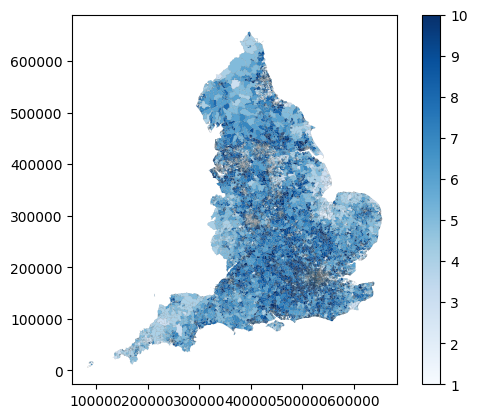

In [7]:
problem.plot_region_geometry_layer(plot_equity=True, linewidth=0.03)

However, this is not that useful to us as it's very zoomed out and showing the whole dataset (as our region geometry layer is for the whole of England too). 

However, we have passed in demand data for only our region of interest, so if we set 'plot_region_of_interest_only' to True, it will limit the output plot to that region. 

<Axes: >

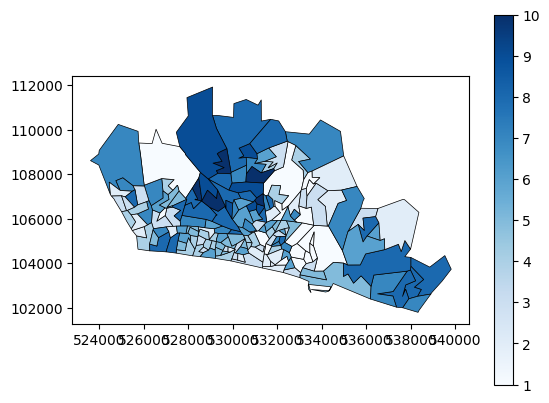

In [8]:
problem.plot_region_geometry_layer(
    plot_equity=True,
    plot_region_of_interest_only=True
    )

We can change the colourmap to something else. 

<Axes: >

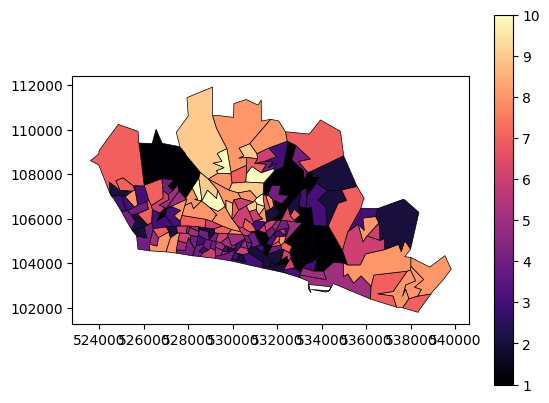

In [9]:
problem.plot_region_geometry_layer(
    plot_equity=True,
    plot_region_of_interest_only=True,
    cmap="magma"
    )

We can also opt to plot it in an interactive format instead. 

In [10]:
problem.plot_region_geometry_layer(
    plot_equity=True,
    plot_region_of_interest_only=True,
    interactive=True
    )

Let's now solve the problem. 

In [11]:
solutions = problem.solve(p=4, objectives="p_median", threshold_for_coverage=10)
solutions.show_solutions()

  0%|          | 0/15 [00:00<?, ?it/s]

,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,"[Site 1, Site 3, Site 4, Site 5]","[0, 2, 3, 4]",10,5.08,5.12,7.82,16.69,0.96,LSOA L...
1,"[Site 3, Site 4, Site 5, Site 6]","[2, 3, 4, 5]",10,5.11,5.05,7.42,16.69,0.96,LSOA L...
2,"[Site 2, Site 3, Site 4, Site 6]","[1, 2, 3, 5]",10,5.20,5.07,7.75,16.69,0.95,LSOA L...
3,"[Site 1, Site 2, Site 3, Site 4]","[0, 1, 2, 3]",10,5.22,5.21,8.34,16.69,0.95,LSOA L...
4,"[Site 1, Site 3, Site 4, Site 6]","[0, 2, 3, 5]",10,5.23,5.19,8.06,16.69,0.95,LSOA L...
5,"[Site 2, Site 3, Site 4, Site 5]","[1, 2, 3, 4]",10,5.28,5.33,8.32,16.69,0.95,LSOA L...
6,"[Site 1, Site 3, Site 5, Site 6]","[0, 2, 4, 5]",10,6.05,5.90,9.07,16.69,0.95,LSOA L...
7,"[Site 1, Site 2, Site 3, Site 6]","[0, 1, 2, 5]",10,6.14,5.92,9.33,16.69,0.94,LSOA L...
8,"[Site 1, Site 2, Site 3, Site 5]","[0, 1, 2, 4]",10,6.24,6.17,9.69,16.69,0.92,LSOA L...
9,"[Site 2, Site 3, Site 5, Site 6]","[1, 2, 4, 5]",10,6.33,6.17,9.26,16.69,0.93,LSOA L...


In [12]:
example_problem_df = solutions.show_solutions()["problem_df"].iloc[0]

In [13]:
example_problem_df

,LSOA,LSOA_x,Site 1,Site 3,Site 4,Site 5,min_cost,selected_site,within_threshold,LSOA_y,demand,LSOA11NM,IMD15,IMD15_raw
0,Brighton and Hove 027E,Brighton and Hove 027E,12.898833,7.404833,8.197500,10.125667,7.404833,Site 3,True,Brighton and Hove 027E,3627,Brighton and Hove 027E,2,5040
1,Brighton and Hove 027F,Brighton and Hove 027F,12.623167,8.626167,9.351167,9.649500,8.626167,Site 3,True,Brighton and Hove 027F,2323,Brighton and Hove 027F,3,9104
2,Brighton and Hove 027A,Brighton and Hove 027A,12.720667,8.633000,6.840000,11.353833,6.840000,Site 4,True,Brighton and Hove 027A,2596,Brighton and Hove 027A,3,7483
3,Brighton and Hove 029E,Brighton and Hove 029E,12.393667,11.006000,6.328667,12.193000,6.328667,Site 4,True,Brighton and Hove 029E,3132,Brighton and Hove 029E,2,6218
4,Brighton and Hove 029D,Brighton and Hove 029D,11.097500,10.970000,5.216667,12.408333,5.216667,Site 4,True,Brighton and Hove 029D,2883,Brighton and Hove 029D,3,7018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,Brighton and Hove 012A,Brighton and Hove 012A,7.442333,18.468500,8.652667,10.433667,7.442333,Site 1,True,Brighton and Hove 012A,2497,Brighton and Hove 012A,3,8891
161,Brighton and Hove 005C,Brighton and Hove 005C,7.830000,16.804000,9.490000,8.769167,7.830000,Site 1,True,Brighton and Hove 005C,2570,Brighton and Hove 005C,2,5951
162,Brighton and Hove 012B,Brighton and Hove 012B,7.742167,18.876667,8.952500,10.841833,7.742167,Site 1,True,Brighton and Hove 012B,2051,Brighton and Hove 012B,3,8814
163,Brighton and Hove 005A,Brighton and Hove 005A,9.458167,18.432167,11.068500,10.397333,9.458167,Site 1,True,Brighton and Hove 005A,1164,Brighton and Hove 005A,7,21094


In [14]:
example_problem_df.groupby("IMD15")['min_cost'].agg("mean").round(2).reset_index()

,IMD15,min_cost
0,1,4.74
1,2,6.23
2,3,5.50
3,4,4.14
4,5,3.61
5,6,4.47
6,7,5.63
7,8,6.30
8,9,5.49
9,10,4.90


In [15]:
solutions.check_solution_equity()

,IMD15,min_cost
0,1,4.74
1,2,6.23
2,3,5.50
3,4,4.14
4,5,3.61
5,6,4.47
6,7,5.63
7,8,6.30
8,9,5.49
9,10,4.90


In [16]:
solutions.check_solution_equity(return_plot=True)

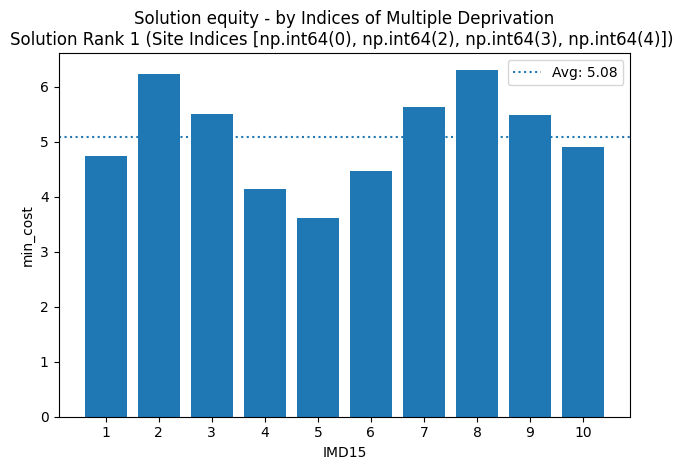

In [17]:
solutions.check_solution_equity(return_plot=True, interactive=False);

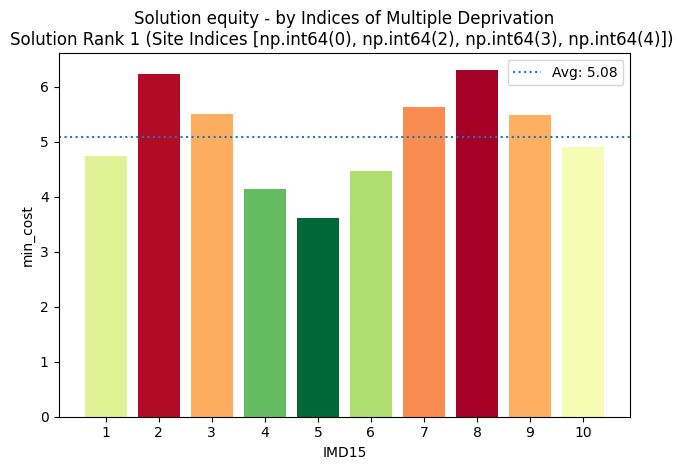

In [18]:
solutions.check_solution_equity(return_plot=True, interactive=False, colour_mode="gradient");

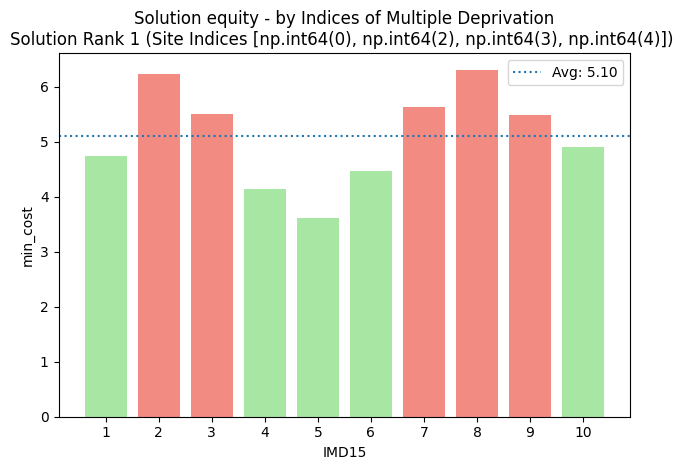

In [19]:
solutions.check_solution_equity(return_plot=True, interactive=False, colour_mode="above_below_avg");

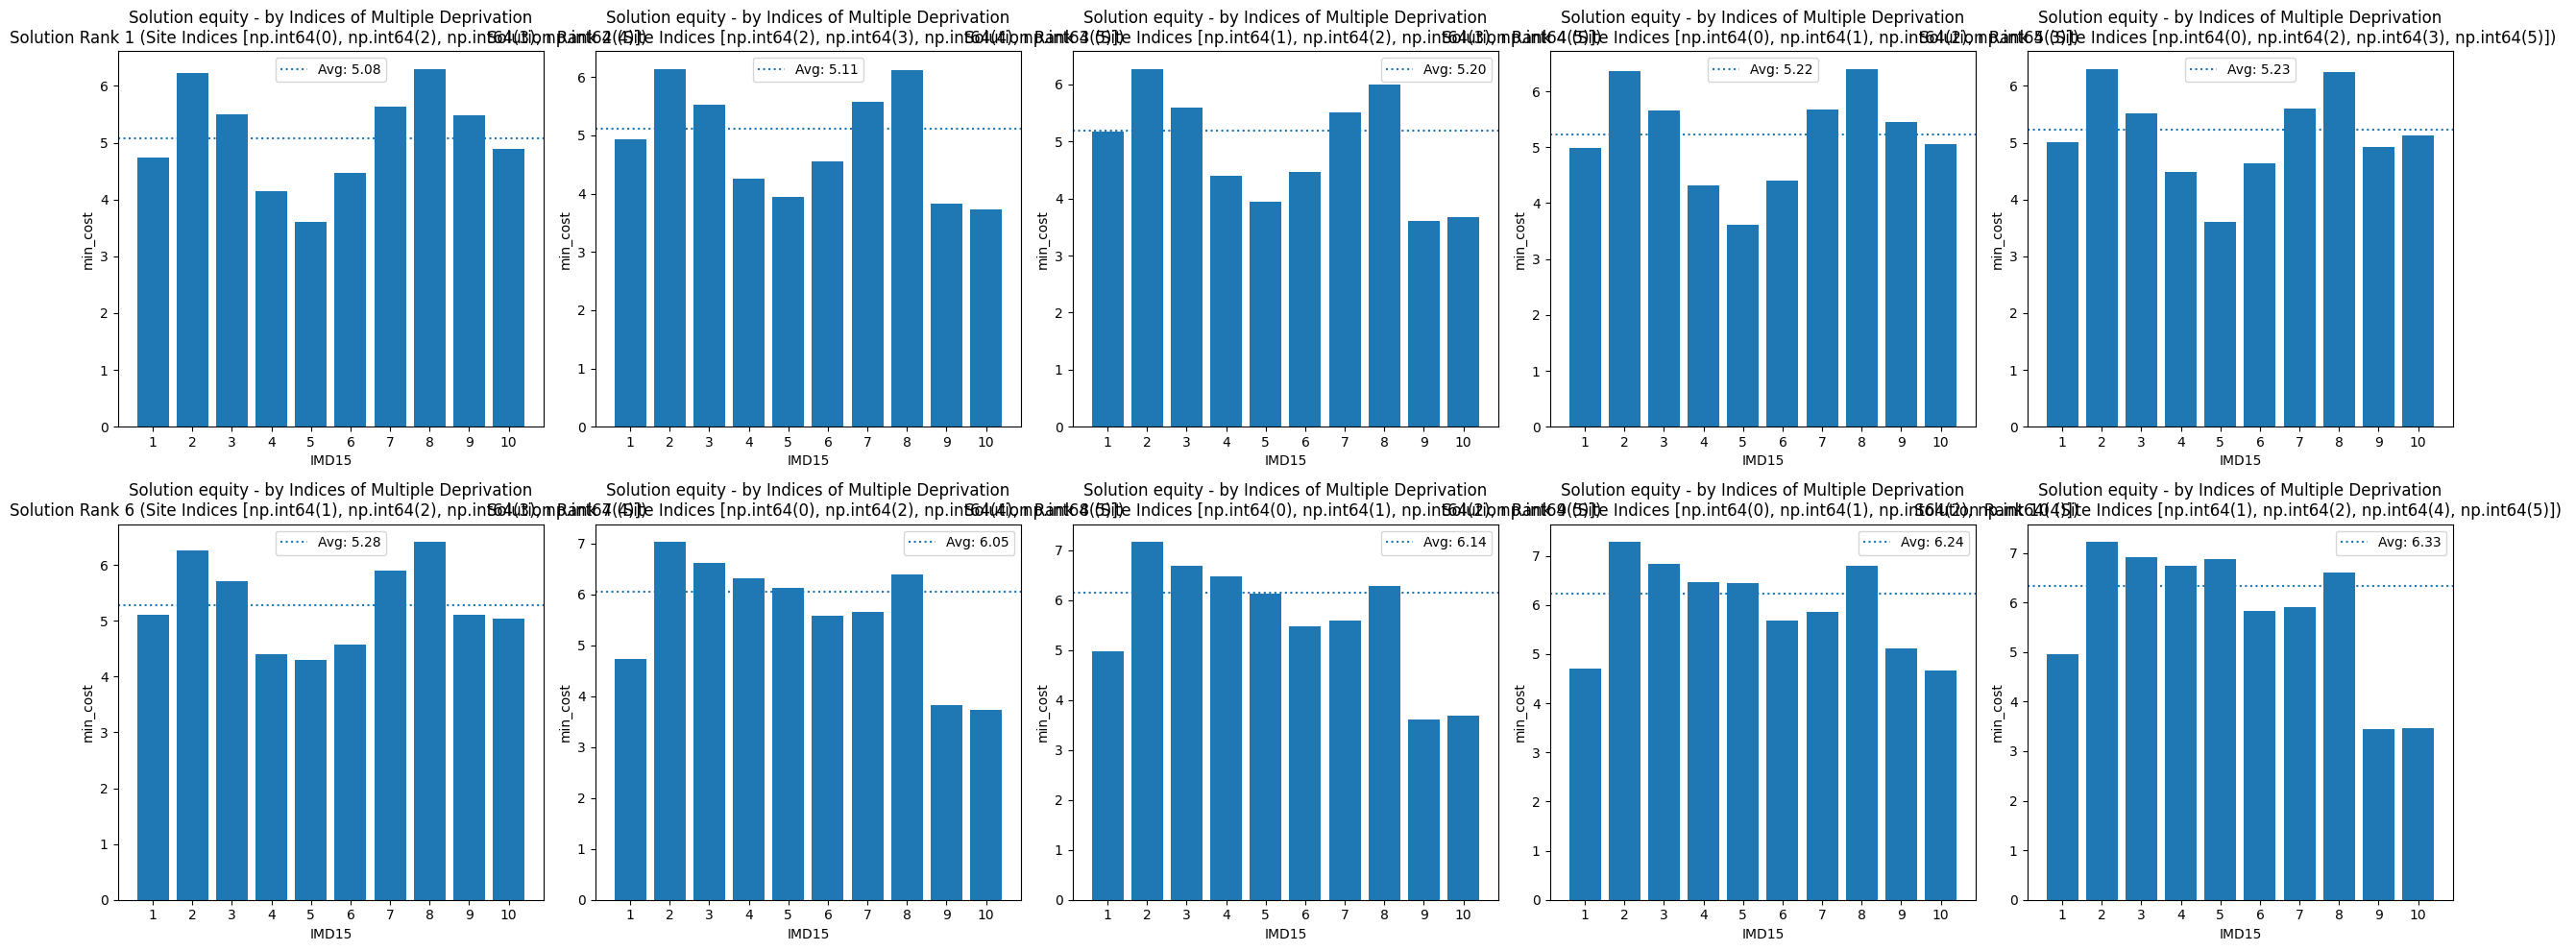

In [20]:
solutions.plot_top_n_solution_equity(cols=5, n=10);

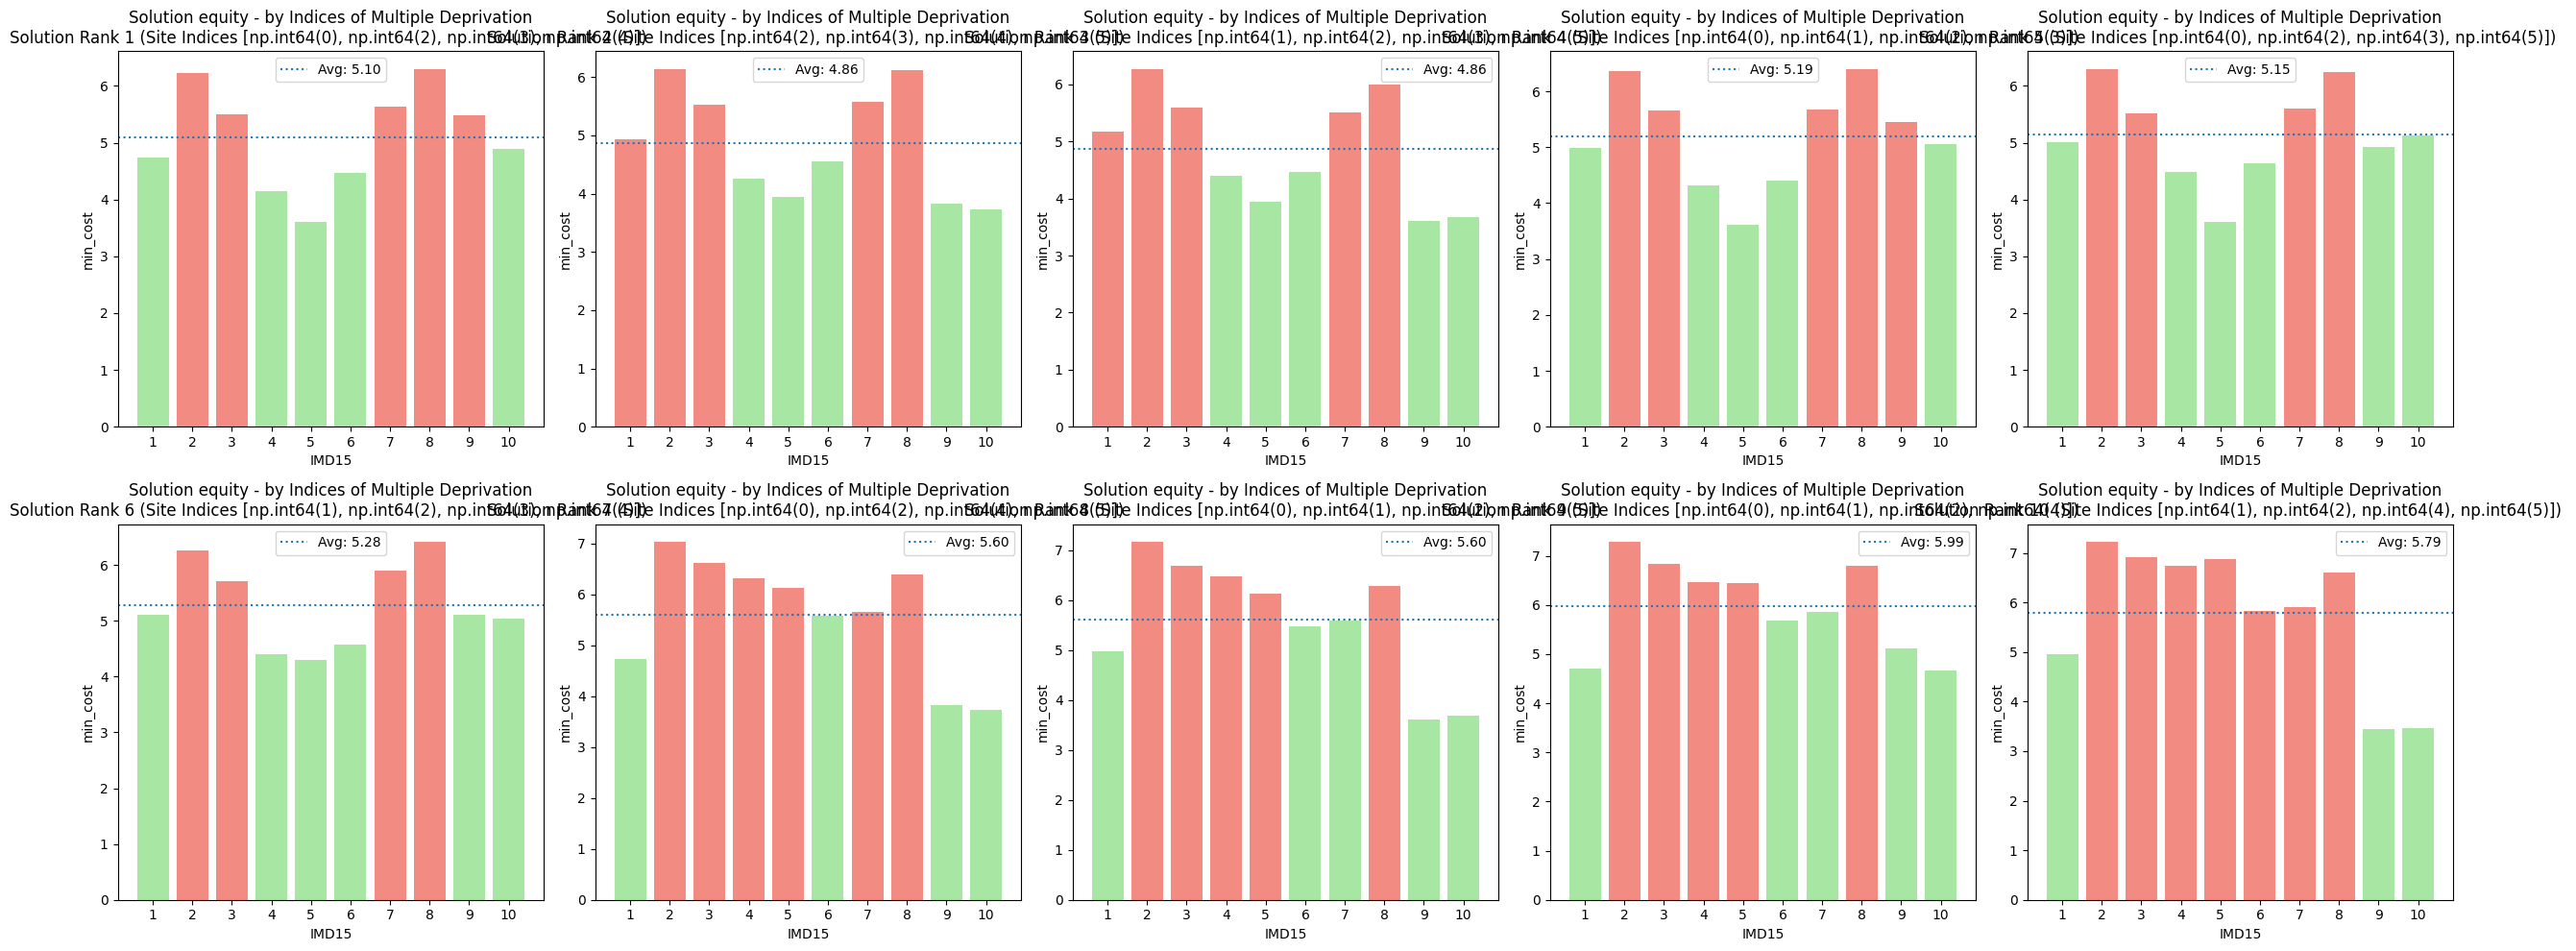

In [21]:
solutions.plot_top_n_solution_equity(cols=5, n=10, colour_mode="above_below_avg");

We can see for example that solution 2 is slightly worse for the most deprived group (IMD 1) than solution 1. 

In [22]:
example_problem_df

,LSOA,LSOA_x,Site 1,Site 3,Site 4,Site 5,min_cost,selected_site,within_threshold,LSOA_y,demand,LSOA11NM,IMD15,IMD15_raw
0,Brighton and Hove 027E,Brighton and Hove 027E,12.898833,7.404833,8.197500,10.125667,7.404833,Site 3,True,Brighton and Hove 027E,3627,Brighton and Hove 027E,2,5040
1,Brighton and Hove 027F,Brighton and Hove 027F,12.623167,8.626167,9.351167,9.649500,8.626167,Site 3,True,Brighton and Hove 027F,2323,Brighton and Hove 027F,3,9104
2,Brighton and Hove 027A,Brighton and Hove 027A,12.720667,8.633000,6.840000,11.353833,6.840000,Site 4,True,Brighton and Hove 027A,2596,Brighton and Hove 027A,3,7483
3,Brighton and Hove 029E,Brighton and Hove 029E,12.393667,11.006000,6.328667,12.193000,6.328667,Site 4,True,Brighton and Hove 029E,3132,Brighton and Hove 029E,2,6218
4,Brighton and Hove 029D,Brighton and Hove 029D,11.097500,10.970000,5.216667,12.408333,5.216667,Site 4,True,Brighton and Hove 029D,2883,Brighton and Hove 029D,3,7018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,Brighton and Hove 012A,Brighton and Hove 012A,7.442333,18.468500,8.652667,10.433667,7.442333,Site 1,True,Brighton and Hove 012A,2497,Brighton and Hove 012A,3,8891
161,Brighton and Hove 005C,Brighton and Hove 005C,7.830000,16.804000,9.490000,8.769167,7.830000,Site 1,True,Brighton and Hove 005C,2570,Brighton and Hove 005C,2,5951
162,Brighton and Hove 012B,Brighton and Hove 012B,7.742167,18.876667,8.952500,10.841833,7.742167,Site 1,True,Brighton and Hove 012B,2051,Brighton and Hove 012B,3,8814
163,Brighton and Hove 005A,Brighton and Hove 005A,9.458167,18.432167,11.068500,10.397333,9.458167,Site 1,True,Brighton and Hove 005A,1164,Brighton and Hove 005A,7,21094


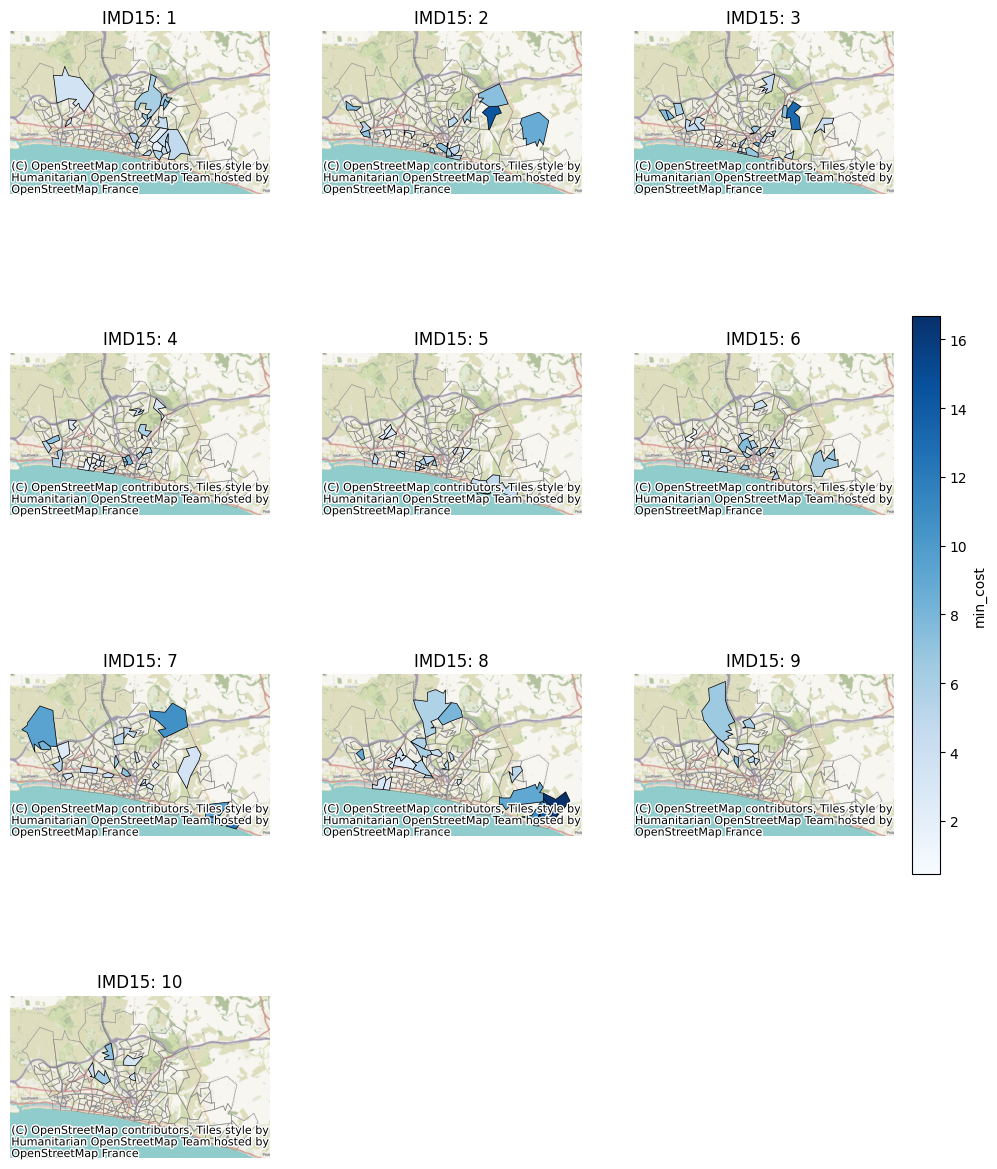

In [23]:
solutions.plot_combination_by_equity();

We can also choose to limit this to just certain groups.

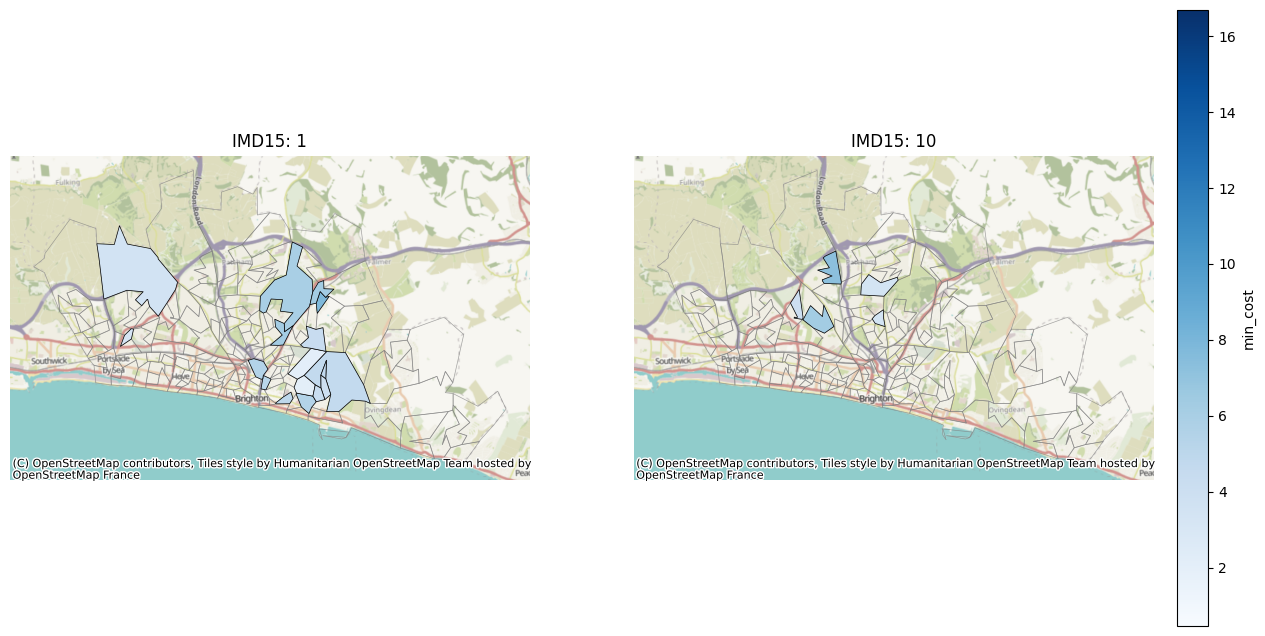

In [24]:
solutions.plot_combination_by_equity(groups_to_include=[1,10], figsize_multiplier=8);

We can also combine multiple groups to display in a single plot.

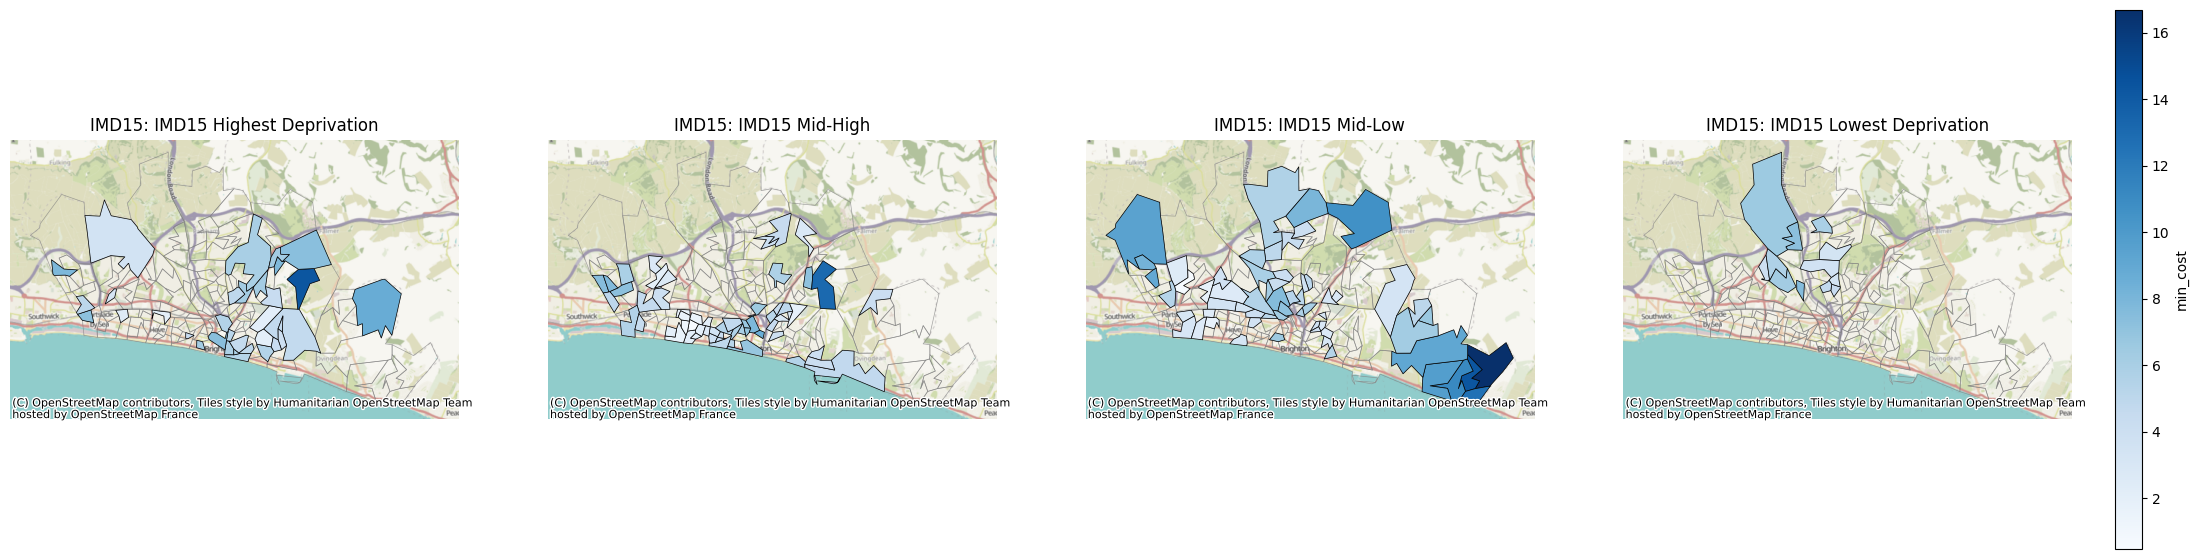

In [28]:
groupings = {
    "IMD15 Highest Deprivation": [1, 2],
    "IMD15 Mid-High": [3, 4, 5],
    "IMD15 Mid-Low": [6, 7, 8],
    "IMD15 Lowest Deprivation": [9, 10],
}

solutions.plot_combination_by_equity(groupings=groupings, figsize_multiplier=7, ncols=4);